In [1]:
import pandas as pd
import numpy as np
import sklearn
import xgboost as xgb
import optuna
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    root_mean_squared_error,
    mean_absolute_error,
    r2_score,
)
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score

In [2]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [3]:
# Check CUDA installation and version
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Nov__7_19:25:04_Pacific_Standard_Time_2025
Cuda compilation tools, release 13.1, V13.1.80
Build cuda_13.1.r13.1/compiler.36836380_0


In [4]:
# Check for GPU access
!nvidia-smi

Sun Jul  5 22:04:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 576.28                 Driver Version: 576.28         CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3060 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   47C    P8             11W /  105W |      88MiB /   6144MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
from sklearn.datasets import fetch_california_housing
data = fetch_california_housing()
X, y = data.data, data.target

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
print(f"X_train.shape:{X_train.shape}\nX_test.shape:{X_train.shape}")

X_train.shape:(16512, 8)
X_test.shape:(16512, 8)


In [15]:
# Baseline model
model = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
mse_model = mean_squared_error(y_test, y_pred)
rmse_model = root_mean_squared_error(y_test, y_pred)
mae_model = mean_absolute_error(y_test, y_pred)
r2_model = r2_score(y_test, y_pred)

print(f"MSE :  {mse_model:.4f}")
print(f"RMSE:  {rmse_model:.4f}")
print(f"MAE :  {mae_model:.4f}")
print(f"R²  :  {r2_model:.4f}")

MSE :  0.2226
RMSE:  0.4718
MAE :  0.3096
R²  :  0.8301


In [9]:
# Objective function for Optuna
def objective(trial):

    params = {
        "objective": "reg:squarederror",
        "random_state": 42,

        # Boosting
        "learning_rate": trial.suggest_float("learning_rate",0.01, 0.15, log=True,),

        "n_estimators": trial.suggest_int("n_estimators",200,3000,),

        # Tree Complexity
        "max_depth": trial.suggest_int("max_depth",3,8, ),

        "min_child_weight": trial.suggest_int("min_child_weight",1,15,),

        "gamma": trial.suggest_float("gamma",0,3,),

        # Randomness
        "subsample": trial.suggest_float("subsample",0.6,1.0,),

        "colsample_bytree": trial.suggest_float("colsample_bytree",0.6,1.0,),

        # Regularization
        "reg_alpha": trial.suggest_float("reg_alpha",1e-4,10,log=True,),

        "reg_lambda": trial.suggest_float("reg_lambda",1e-3,20,log=True,),
    }

    model = xgb.XGBRegressor(**params,tree_method= "hist",verbosity = 0)

    score = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
    ).mean()

    return score

sampler = optuna.samplers.TPESampler(
    seed=42,
    multivariate=True,
    n_startup_trials=20,
    n_ei_candidates=48,
)

study = optuna.create_study(
    study_name="objective",
    direction="maximize",
    sampler=sampler,
)

C:\.venv\lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(


In [10]:
%time
study.optimize(objective, n_trials=500, show_progress_bar=True, n_jobs= -1)

CPU times: total: 0 ns
Wall time: 0 ns


  0%|          | 0/500 [00:00<?, ?it/s]

In [11]:
# Retrieve the best parameter values
best_params = study.best_params
print(f"\nBest parameters: {best_params}")


Best parameters: {'learning_rate': 0.05929265231626775, 'n_estimators': 1844, 'max_depth': 5, 'min_child_weight': 5, 'gamma': 0.8782696832607649, 'subsample': 0.6067331992878259, 'colsample_bytree': 0.9907678043391831, 'reg_alpha': 0.0003623830817643263, 'reg_lambda': 4.3718772256502225}


In [12]:
best_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    **study.best_params,
)

In [13]:
best_model.fit(X_train, y_train)

# Predict on the test set
y_pred = best_model.predict(X_test)

# Evaluation metrics
mse_best_model = mean_squared_error(y_test, y_pred)
rmse_best_model = root_mean_squared_error(y_test, y_pred)
mae_best_model = mean_absolute_error(y_test, y_pred)
r2_best_model = r2_score(y_test, y_pred)

print(f"MSE :  {mse_best_model:.4f}")
print(f"RMSE:  {rmse_best_model:.4f}")
print(f"MAE :  {mae_best_model:.4f}")
print(f"R²  :  {r2_best_model:.4f}")

MSE :  0.2101
RMSE:  0.4583
MAE :  0.3068
R²  :  0.8397


In [16]:
import pandas as pd

results = pd.DataFrame(
    {
        "Baseline": [
            mse_model,
            rmse_model,
            mae_model,
            r2_model,
        ],
        "Optuna": [
            mse_best_model,
            rmse_best_model,
            mae_best_model,
            r2_best_model,
        ],
    },
    index=["MSE", "RMSE", "MAE", "R²"],
)

# Absolute change (Optuna - Baseline)
results["Change"] = results["Optuna"] - results["Baseline"]

# Percentage change relative to Baseline
results["Change (%)"] = (
    results["Change"] / results["Baseline"] * 100
)

results = results.round(4)

results

,Baseline,Optuna,Change,Change (%)
MSE,0.2226,0.2101,-0.0125,-5.6201
RMSE,0.4718,0.4583,-0.0134,-2.8507
MAE,0.3096,0.3068,-0.0027,-0.8816
R²,0.8301,0.8397,0.0095,1.1500


In [17]:
# https://xgboosting.com/xgboost-for-the-california-housing-dataset/

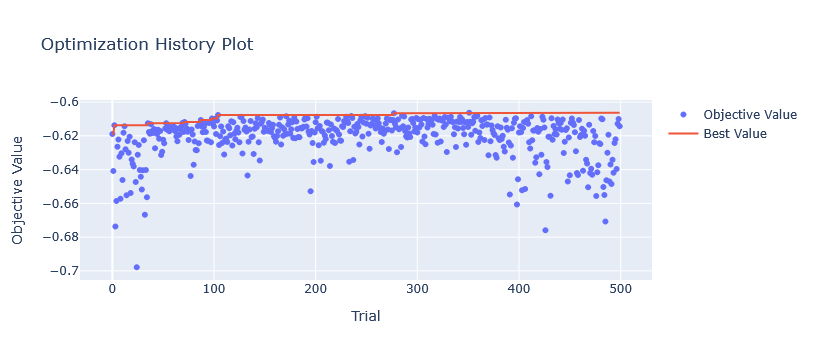

In [18]:
optuna.visualization.plot_optimization_history(study)

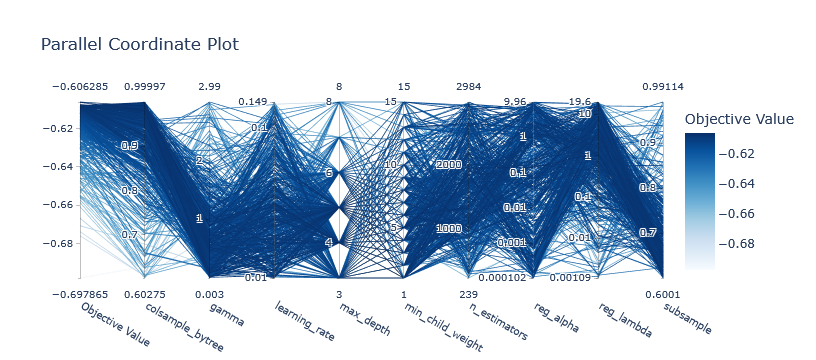

In [19]:
optuna.visualization.plot_parallel_coordinate(study)

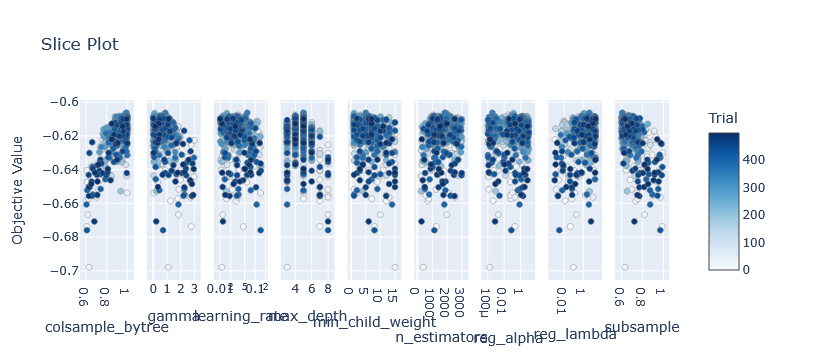

In [20]:
optuna.visualization.plot_slice(study)

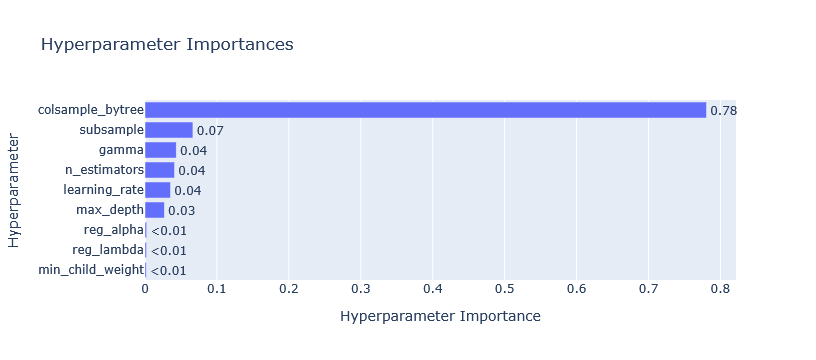

In [21]:
optuna.visualization.plot_param_importances(study)

C:\Users\SL\AppData\Local\Temp\ipykernel_6040\4136363031.py:1: ExperimentalWarning: optuna.visualization._terminator_improvement.plot_terminator_improvement is experimental (supported from v3.2.0). The interface can change in the future.
  optuna.visualization.plot_terminator_improvement(study)
C:\.venv\lib\site-packages\optuna\visualization\_terminator_improvement.py:97: ExperimentalWarning: RegretBoundEvaluator is experimental (supported from v3.2.0). The interface can change in the future.
  improvement_evaluator = RegretBoundEvaluator()
C:\.venv\lib\site-packages\optuna\visualization\_terminator_improvement.py:102: ExperimentalWarning: CrossValidationErrorEvaluator is experimental (supported from v3.2.0). The interface can change in the future.
  error_evaluator = CrossValidationErrorEvaluator()
100%|████████████████████████████████████████████████████████████████████████████████| 500/500 [01:41<00:00,  4.92it/s]


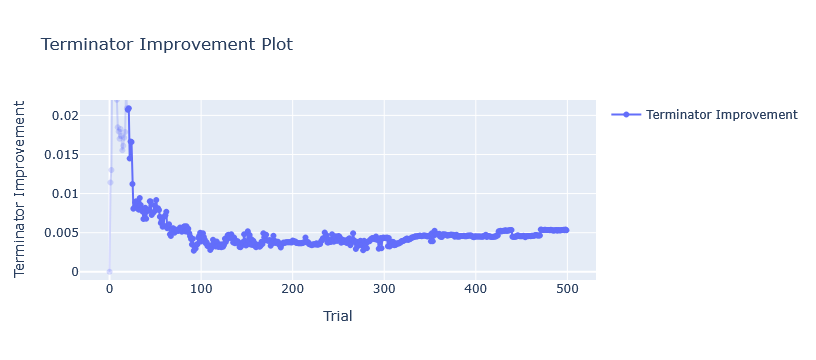

In [22]:
optuna.visualization.plot_terminator_improvement(study)